 This file contains the script for training binary and multi-class CNN's, optimizing it with Optuna, running performance metrics, and customized GRAD-CAM for 1D spectral data. 

1. Load in the libraries for CNN + GRAD-CAM

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping
import optuna
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import label_binarize
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

Ensure all RM spectra and pre-processed and normalized, refer to scripts --> 

 https://github.com/Tissue-Engineering-BioImaging-Lab/Raman-Analysis_Preprocessing-and-ML- 

1. Load and Prep the Data

In [2]:
def prepare_data(csv_path, test_size=0.2, random_state=42, stratify=True):
    # Load your CSV file
    data = pd.read_csv(csv_path)
    data = data.drop(index=0).reset_index(drop=True)  # Drop first row (x-axis), reset index

    # Assuming the last column is the label
    X = data.iloc[:, :-1].values  # spectra
    y = data.iloc[:, -1].values   # labels

    # Standardize the spectra
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Convert labels to numeric if necessary
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Split the dataset
    stratify_arg = y if stratify else None
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_arg
    )

    # Reshape for 1D CNN [samples, time steps, channels]
    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    return X_train, X_test, y_train, y_test, le, scaler


2. Add the Data

In [3]:
def prepare_data_binary(csv_path, positive_label=1, negative_label=4, test_size=0.2, random_state=42, stratify=True):
    data = pd.read_csv(csv_path)
    data = data.drop(index=0).reset_index(drop=True)

    # filter to binary labels only
    data = data[data.iloc[:, -1].isin([positive_label, negative_label])].reset_index(drop=True)

    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    stratify_arg = y if stratify else None
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_arg
    )

    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    return X_train, X_test, y_train, y_test, le, scaler


In [12]:
data_path = "Binary_Test_ANN_CNN_data.csv"  # Binary dataset (leave as is)
data_path_multi = "Test_ANN_CNN_data.csv"  # Multiclass dataset path

X_train_multi, X_test_multi, y_train_multi, y_test_multi, le_multi, scaler_multi = prepare_data(data_path_multi)


Binary CNN Model Architecture

In [18]:
def build_binary_cnn_model(trial, input_shape):
    
    model = Sequential([
        Conv1D(trial.suggest_int("b_filters1", 16, 128, step=16),
               trial.suggest_int("b_kernel1", 3, 9, step=2),
               activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(trial.suggest_int("b_pool1", 2, 4)),

        Conv1D(trial.suggest_int("b_filters2", 16, 128, step=16),
               trial.suggest_int("b_kernel2", 3, 9, step=2),
               activation='relu'),
        BatchNormalization(),
        MaxPooling1D(trial.suggest_int("b_pool2", 2, 4)),

        Flatten(),
        Dropout(trial.suggest_float("b_dropout", 0.2, 0.7)),
        Dense(trial.suggest_int("b_dense", 32, 256, step=32), activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    lr = trial.suggest_float("b_lr", 1e-5, 1e-2, log=True)
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def objective_binary(trial):
    X_train, X_test, y_train, y_test, le, scaler = prepare_data_binary(data_path)

    model = build_binary_cnn_model(trial, X_train.shape[1:])

    epochs = trial.suggest_int("b_epochs", 10, 40)
    batch_size = trial.suggest_int("b_batch", 16, 128, step=16)

    early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    y_pred = (model.predict(X_test) > 0.5).astype(int).ravel()
    acc = accuracy_score(y_test, y_pred)
    return acc

def evaluate_cnn_model(binary_model, X_test, y_test, class_names):
    # Predict on test data
    y_pred_prob = binary_model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    # Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma', cbar=True,
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # Performance metrics
    from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
    print("Classification report:", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # ROC
    y_pred_prob = binary_model.predict(X_test).ravel()
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return cm, y_pred 

a. Run Optuna

In [6]:
study_binary = optuna.create_study(direction="maximize")
study_binary.optimize(objective_binary, n_trials=5) #Change this to as many trials as you like, 5 is just an arbritary number :)

print("Best binary accuracy:", study_binary.best_value)
print("Best binary params:", study_binary.best_params)

[I 2026-02-18 11:33:22,704] A new study created in memory with name: no-name-580b2de5-832b-4398-b5b4-22e48b7bc4da
/Users/natashakunchur/Desktop/Test Analysis/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-18 11:33:22.758955: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-02-18 11:33:22.759182: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-18 11:33:22.759199: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-02-18 11:33:22.759253: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


[I 2026-02-18 11:33:34,843] Trial 0 finished with value: 0.95 and parameters: {'b_filters1': 96, 'b_kernel1': 3, 'b_pool1': 4, 'b_filters2': 64, 'b_kernel2': 3, 'b_pool2': 2, 'b_dropout': 0.23210586456807447, 'b_dense': 128, 'b_lr': 0.002505207551724049, 'b_epochs': 31, 'b_batch': 64}. Best is trial 0 with value: 0.95.
/Users/natashakunchur/Desktop/Test Analysis/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 461ms/step


[I 2026-02-18 11:33:41,672] Trial 1 finished with value: 1.0 and parameters: {'b_filters1': 64, 'b_kernel1': 9, 'b_pool1': 4, 'b_filters2': 48, 'b_kernel2': 9, 'b_pool2': 2, 'b_dropout': 0.6706324949225819, 'b_dense': 256, 'b_lr': 0.0005453063899377348, 'b_epochs': 13, 'b_batch': 32}. Best is trial 1 with value: 1.0.
/Users/natashakunchur/Desktop/Test Analysis/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step


[I 2026-02-18 11:33:55,230] Trial 3 finished with value: 0.5 and parameters: {'b_filters1': 80, 'b_kernel1': 7, 'b_pool1': 3, 'b_filters2': 48, 'b_kernel2': 5, 'b_pool2': 3, 'b_dropout': 0.2583433159845299, 'b_dense': 192, 'b_lr': 0.0011726376680633243, 'b_epochs': 22, 'b_batch': 96}. Best is trial 1 with value: 1.0.
/Users/natashakunchur/Desktop/Test Analysis/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step


[I 2026-02-18 11:34:00,504] Trial 4 finished with value: 0.95 and parameters: {'b_filters1': 80, 'b_kernel1': 7, 'b_pool1': 3, 'b_filters2': 112, 'b_kernel2': 9, 'b_pool2': 3, 'b_dropout': 0.6585127202553716, 'b_dense': 192, 'b_lr': 0.001158325951650842, 'b_epochs': 20, 'b_batch': 16}. Best is trial 1 with value: 1.0.


Best binary accuracy: 1.0
Best binary params: {'b_filters1': 64, 'b_kernel1': 9, 'b_pool1': 4, 'b_filters2': 48, 'b_kernel2': 9, 'b_pool2': 2, 'b_dropout': 0.6706324949225819, 'b_dense': 256, 'b_lr': 0.0005453063899377348, 'b_epochs': 13, 'b_batch': 32}


c. Train best OPTUNA hyperparameterized model

In [ ]:
# Train best model
best_b = study_binary.best_params

def build_binary_from_params(params, input_shape):
    model = Sequential([
        Conv1D(params["b_filters1"], params["b_kernel1"], activation="relu", input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(params["b_pool1"]),

        Conv1D(params["b_filters2"], params["b_kernel2"], activation="relu"),
        BatchNormalization(),
        MaxPooling1D(params["b_pool2"]),

        Flatten(),
        Dropout(params["b_dropout"]),
        Dense(params["b_dense"], activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=Adam(params["b_lr"]), loss="binary_crossentropy", metrics=["accuracy"])
    return model

X_train, X_test, y_train, y_test, le, scaler = prepare_data_binary(data_path)
binary_best_model = build_binary_from_params(best_b, X_train.shape[1:])

history = binary_best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=best_b["b_epochs"],
    batch_size=best_b["b_batch"],
    callbacks=[EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)], 
    verbose=1
)

binary_best_model.save("best_binary_cnn.keras")


Epoch 1/13


/Users/natashakunchur/Desktop/Test Analysis/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.8889 - loss: 0.4692 - val_accuracy: 0.8438 - val_loss: 0.3706
Epoch 2/13
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9603 - loss: 0.2499 - val_accuracy: 0.9375 - val_loss: 0.2712
Epoch 3/13
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9921 - loss: 0.0197 - val_accuracy: 0.9375 - val_loss: 0.2010
Epoch 4/13
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9841 - loss: 0.0501 - val_accuracy: 0.9062 - val_loss: 0.2193
Epoch 5/13
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9921 - loss: 0.0116 - val_accuracy: 0.8438 - val_loss: 0.3378


This is your hyperparameter optimized Binary CNN

In [8]:
binary_best_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 381, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 381, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 95, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 87, 48)         │        27,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 87, 48)         │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 43, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2064)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2064)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       528,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,672,597 (6.38 MB)

 Trainable params: 557,457 (2.13 MB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 1,114,916 (4.25 MB)

d. Evaluate Binary CNN Performance Metrics

In [19]:
# Load saved CNN Binary Model
binary_CNN_model = load_model("best_binary_cnn.keras", compile=False)

label_map = {1: "Asthmatic Epithelium", 4: "Control Epithelium"}
class_names = [label_map[int(x)] for x in le.classes_]

# Evaluate
cm, y_pred = evaluate_cnn_model(binary_CNN_model, X_test, y_test, class_names)

# Train vs Validation Accuracy and Loss Plot (use training history from best model)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


KeyError: 2

GRAD CAM Implementation (Binary and Multi-class same logic)

gradcam_1d(...)
- Rebuilds the model’s forward pass with a new input tensor.
- Grabs the output of the chosen Conv1D layer (conv1d_166).
- Computes Grad‑CAM for a specific class by taking gradients of that class score w.r.t. the conv feature map.
- Produces a 1D importance curve (CAM) over the conv layer’s time axis.

class_average_gradcam(...)
- Loops through all samples in X.
- Keeps only those whose true label equals the target class.
- Runs gradcam_1d on each of those samples.
- Returns the average CAM across all samples in that class.
- Reads the wavenumber axis from the CSV header (all columns except the label column).

For each class (1–6):
- Converts your original label (1–6) to the encoded label index used by the model.
- Computes the class‑average CAM.
- Upsamples the CAM to match the number of wavenumbers (so it can be plotted on the real x‑axis).
= Plots one graph per class showing importance vs. wavenumber.
- Prints a list of (wavenumber, importance) values for that class.
- So the end result is: six plots (one per class) and a text list of wavenumber importance values for each class.

2. GRAD-CAM for Binary CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step


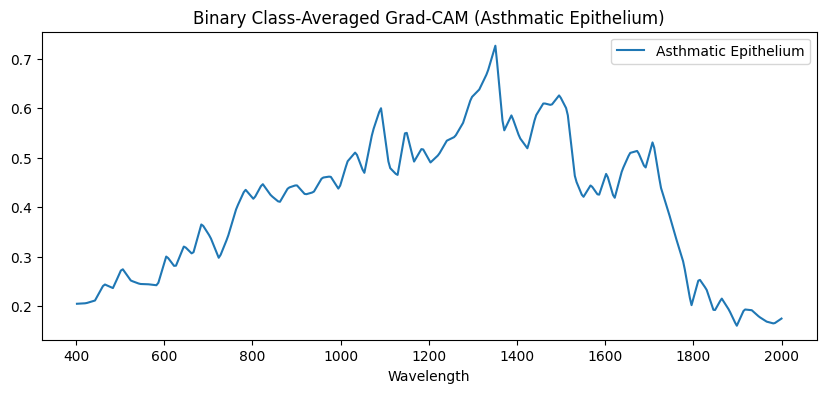


Asthmatic Epithelium — wavenumber importance:
402.1287	0.204656
406.6808	0.204887
411.2303	0.205118
415.7773	0.205349
420.3218	0.205580
424.8639	0.206297
429.4034	0.207522
433.9404	0.208748
438.4749	0.209973
443.0069	0.211198
447.5365	0.218415
452.0635	0.225775
456.5881	0.233135
461.1101	0.240495
465.6297	0.243596
470.1469	0.241802
474.6615	0.240007
479.1736	0.238212
483.6833	0.236417
488.1905	0.244900
492.6953	0.253883
497.1975	0.262867
501.6973	0.271851
506.1946	0.274372
510.6895	0.268729
515.1819	0.263087
519.6719	0.257445
524.1594	0.251803
528.6445	0.250029
533.1271	0.248546
537.6072	0.247063
542.0850	0.245580
546.5602	0.244653
551.0330	0.244496
555.5034	0.244340
559.9714	0.244184
564.4369	0.244027
568.9000	0.243581
573.3607	0.243105
577.8188	0.242629
582.2747	0.242153
586.7280	0.247106
591.1790	0.260361
595.6276	0.273617
600.0737	0.286872
604.5174	0.300127
608.9587	0.297050
613.3976	0.291824
617.8340	0.286598
622.2681	0.281372
626.6998	0.281686
631.1290	0.291349
635.5559	0.301013

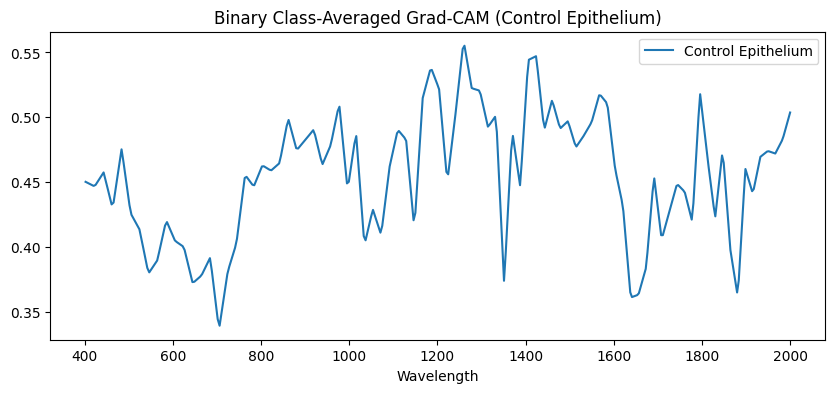


Control Epithelium — wavenumber importance:
402.1287	0.450143
406.6808	0.449358
411.2303	0.448573
415.7773	0.447788
420.3218	0.447003
424.8639	0.447774
429.4034	0.450177
433.9404	0.452580
438.4749	0.454983
443.0069	0.457386
447.5365	0.451368
452.0635	0.445149
456.5881	0.438931
461.1101	0.432712
465.6297	0.434158
470.1469	0.444418
474.6615	0.454679
479.1736	0.464939
483.6833	0.475199
488.1905	0.465167
492.6953	0.454145
497.1975	0.443123
501.6973	0.432101
506.1946	0.424715
510.6895	0.421922
515.1819	0.419129
519.6719	0.416335
524.1594	0.413542
528.6445	0.406334
533.1271	0.398795
537.6072	0.391257
542.0850	0.383718
546.5602	0.380289
551.0330	0.382568
555.5034	0.384847
559.9714	0.387126
564.4369	0.389406
568.9000	0.395820
573.3607	0.402659
577.8188	0.409498
582.2747	0.416336
586.7280	0.419078
591.1790	0.415555
595.6276	0.412031
600.0737	0.408507
604.5174	0.404984
608.9587	0.403646
613.3976	0.402597
617.8340	0.401547
622.2681	0.400497
626.6998	0.397535
631.1290	0.391345
635.5559	0.385154
6

In [10]:

label_map_binary = {
    1: "Asthmatic Epithelium",
    4: "Control Epithelium"
}

def gradcam_1d_binary(model, x, conv_layer_name=None):
    if conv_layer_name is None:
        conv_candidates = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv1D)]
        if not conv_candidates:
            raise ValueError("No Conv1D layers found in model.")
        conv_layer_name = conv_candidates[-1]

    x_in = tf.keras.Input(shape=x.shape[1:])
    h = x_in
    conv_out = None

    for layer in model.layers:
        h = layer(h)
        if layer.name == conv_layer_name:
            conv_out = h

    if conv_out is None:
        raise ValueError(f"Layer {conv_layer_name} not found in model.")

    grad_model = tf.keras.models.Model(x_in, [conv_out, h])

    with tf.GradientTape() as tape:
        conv_out_val, preds = grad_model(x)
        class_score = preds[:, 0]  # sigmoid output

    grads = tape.gradient(class_score, conv_out_val)
    weights = tf.reduce_mean(grads, axis=1)
    cam = tf.reduce_sum(conv_out_val * weights[:, None, :], axis=-1)
    cam = tf.nn.relu(cam)[0].numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

def class_average_gradcam_binary(model, X, y, target_class, conv_layer_name=None):
    cams = []
    for i in range(len(X)):
        if y[i] != target_class:
            continue
        cam = gradcam_1d_binary(model, X[i:i+1], conv_layer_name=conv_layer_name)
        cams.append(cam)

    if len(cams) == 0:
        raise ValueError("No samples found for that class.")
    return np.mean(cams, axis=0)

# ---- Wavelength axis from CSV header ----
df = pd.read_csv(data_path)
wavelengths = df.columns[:-1].astype(float).to_numpy()

# ---- Ensure model is built ----
_ = binary_best_model.predict(X_test[:1])

# ---- One plot per class (labels 1 and 4) ----
encoded_1 = np.where(le.classes_ == 1)[0][0]
encoded_4 = np.where(le.classes_ == 4)[0][0]

for orig_label, enc_label in [(1, encoded_1), (4, encoded_4)]:
    avg_cam = class_average_gradcam_binary(
        binary_best_model, X_test, y_test, target_class=enc_label
    )


    avg_cam_resized = np.interp(
        np.linspace(0, len(avg_cam) - 1, len(wavelengths)),
        np.arange(len(avg_cam)),
        avg_cam
    )

    plt.figure(figsize=(10,4))
    plt.plot(wavelengths, avg_cam_resized, label=label_map_binary[orig_label])
    plt.xlabel("Wavelength")
    plt.title(f"Binary Class‑Averaged Grad‑CAM ({label_map_binary[orig_label]})")
    plt.legend()
    plt.show()

    print(f"\n{label_map_binary[orig_label]} — wavenumber importance:")
    for wn, imp in zip(wavelengths, avg_cam_resized):
        print(f"{wn:.4f}\t{imp:.6f}")


2. Multi-class CNN Model Architecture + Evaluation Functions

In [13]:
def build_multiclass_cnn_model(trial, input_shape, num_classes):
    model = Sequential([
        Conv1D(trial.suggest_int("m_filters1", 16, 128, step=16),
               trial.suggest_int("m_kernel1", 3, 9, step=2),
               activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(trial.suggest_int("m_pool1", 2, 4)),

        Conv1D(trial.suggest_int("m_filters2", 16, 128, step=16),
               trial.suggest_int("m_kernel2", 3, 9, step=2),
               activation='relu'),
        BatchNormalization(),
        MaxPooling1D(trial.suggest_int("m_pool2", 2, 4)),

        Flatten(),
        Dropout(trial.suggest_float("m_dropout", 0.2, 0.7)),
        Dense(trial.suggest_int("m_dense", 32, 256, step=32), activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    lr = trial.suggest_float("m_lr", 1e-5, 1e-2, log=True)
    model.compile(optimizer=Adam(lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def objective_multiclass(trial):
    X_train, X_test, y_train, y_test, le, scaler = prepare_data(data_path_multi)

    num_classes = len(np.unique(y_train))
    model = build_multiclass_cnn_model(trial, X_train.shape[1:], num_classes)

    epochs = trial.suggest_int("m_epochs", 10, 40)
    batch_size = trial.suggest_int("m_batch", 16, 128, step=16)

    early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred = np.argmax(model.predict(X_test), axis=1)
    acc = accuracy_score(y_test, y_pred)
    return acc

def evaluate_multiclass_model(model, X_test, y_test, class_names):
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    labels = list(range(len(class_names)))

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma', cbar=True,
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted", zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, average="weighted", zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, average="weighted", zero_division=0))
    print("Classification report:", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # ROC (OvR)
    y_test_bin = label_binarize(y_test, classes=labels)
    plt.figure(figsize=(6, 5))
    for i, cls in enumerate(labels):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (OvR)')
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return cm, y_pred


a. Run Optuna to optimize Multi-class CNN hyperparameters

In [ ]:
study_multi = optuna.create_study(direction="maximize")
study_multi.optimize(objective_multiclass, n_trials=2) #Increase trials, this is an arbritary number for testing purposes, you can set it to as many as you like!
print("Best multiclass accuracy:", study_multi.best_value)
print("Best multiclass params:", study_multi.best_params)

[I 2026-02-18 11:42:39,756] A new study created in memory with name: no-name-56479c17-4a80-40da-873d-e07987e515b1
/Users/natashakunchur/Desktop/Test Analysis/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


[I 2026-02-18 11:42:49,851] Trial 0 finished with value: 0.5833333333333334 and parameters: {'m_filters1': 48, 'm_kernel1': 9, 'm_pool1': 4, 'm_filters2': 112, 'm_kernel2': 7, 'm_pool2': 3, 'm_dropout': 0.4405734344446772, 'm_dense': 224, 'm_lr': 0.00020304176973256962, 'm_epochs': 36, 'm_batch': 64}. Best is trial 0 with value: 0.5833333333333334.
/Users/natashakunchur/Desktop/Test Analysis/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step


[I 2026-02-18 11:42:57,937] Trial 1 finished with value: 0.35 and parameters: {'m_filters1': 128, 'm_kernel1': 3, 'm_pool1': 2, 'm_filters2': 64, 'm_kernel2': 3, 'm_pool2': 2, 'm_dropout': 0.35339656653939633, 'm_dense': 96, 'm_lr': 0.0004911609423494126, 'm_epochs': 10, 'm_batch': 16}. Best is trial 0 with value: 0.5833333333333334.


Best multiclass accuracy: 0.5833333333333334
Best multiclass params: {'m_filters1': 48, 'm_kernel1': 9, 'm_pool1': 4, 'm_filters2': 112, 'm_kernel2': 7, 'm_pool2': 3, 'm_dropout': 0.4405734344446772, 'm_dense': 224, 'm_lr': 0.00020304176973256962, 'm_epochs': 36, 'm_batch': 64}


b. Train the hyperparameter optimized Multiclass CNN Model

In [15]:
best_m = study_multi.best_params

def build_multiclass_from_params(params, input_shape, num_classes):
    model = Sequential([
        Conv1D(params["m_filters1"], params["m_kernel1"], activation="relu", input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(params["m_pool1"]),

        Conv1D(params["m_filters2"], params["m_kernel2"], activation="relu"),
        BatchNormalization(),
        MaxPooling1D(params["m_pool2"]),

        Flatten(),
        Dropout(params["m_dropout"]),
        Dense(params["m_dense"], activation="relu"),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer=Adam(params["m_lr"]), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

X_train, X_test, y_train, y_test, le, scaler = prepare_data(data_path_multi)
num_classes = len(np.unique(y_train))

multiclass_best_model = build_multiclass_from_params(best_m, X_train.shape[1:], num_classes)

history_multi = multiclass_best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=best_m["m_epochs"],
    batch_size=best_m["m_batch"],
    callbacks=[EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)],
    verbose=1
)

multiclass_best_model.save("best_multiclass_cnn.keras")

Epoch 1/36


/Users/natashakunchur/Desktop/Test Analysis/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 249ms/step - accuracy: 0.4308 - loss: 2.1892 - val_accuracy: 0.3021 - val_loss: 1.5266
Epoch 2/36
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7546 - loss: 1.1005 - val_accuracy: 0.5417 - val_loss: 1.4275
Epoch 3/36
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8225 - loss: 0.6869 - val_accuracy: 0.6562 - val_loss: 1.3460
Epoch 4/36
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8903 - loss: 0.4523 - val_accuracy: 0.5729 - val_loss: 1.2886
Epoch 5/36
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9217 - loss: 0.2615 - val_accuracy: 0.4688 - val_loss: 1.2566
Epoch 6/36
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9373 - loss: 0.1995 - val_accuracy: 0.3854 - val_loss: 1.2541


This is your Best hyperparameter optimized Mutliclass CNN model parameters

In [16]:
multiclass_best_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_16 (Conv1D)              │ (None, 381, 48)        │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 381, 48)        │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 95, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 89, 112)        │        37,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 89, 112)        │           448 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 29, 112)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 3248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 224)            │       727,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,303,332 (8.79 MB)

 Trainable params: 767,670 (2.93 MB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 1,535,342 (5.86 MB)

c. Mutliclass CNN Model Performance Metrics

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


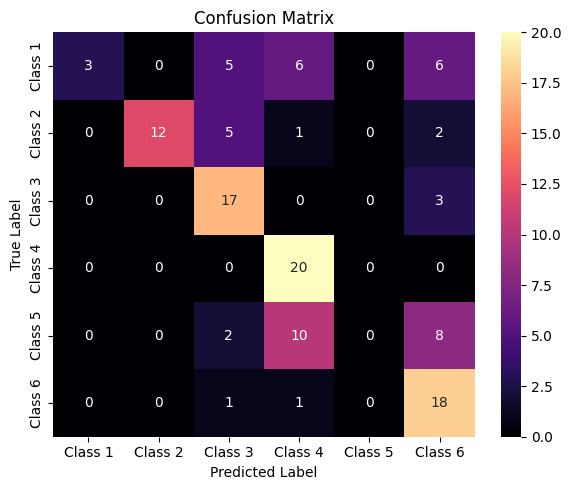

Accuracy: 0.5833333333333334
Precision: 0.5965781571044728
Recall: 0.5833333333333334
F1 Score: 0.5020172808332677
Classification report:               precision    recall  f1-score   support

     Class 1       1.00      0.15      0.26        20
     Class 2       1.00      0.60      0.75        20
     Class 3       0.57      0.85      0.68        20
     Class 4       0.53      1.00      0.69        20
     Class 5       0.00      0.00      0.00        20
     Class 6       0.49      0.90      0.63        20

    accuracy                           0.58       120
   macro avg       0.60      0.58      0.50       120
weighted avg       0.60      0.58      0.50       120



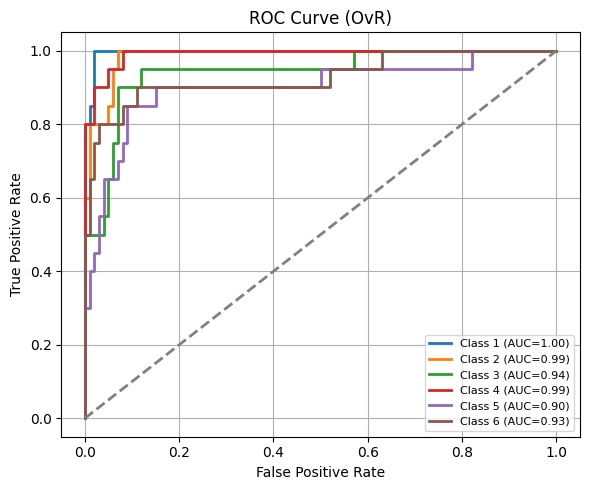

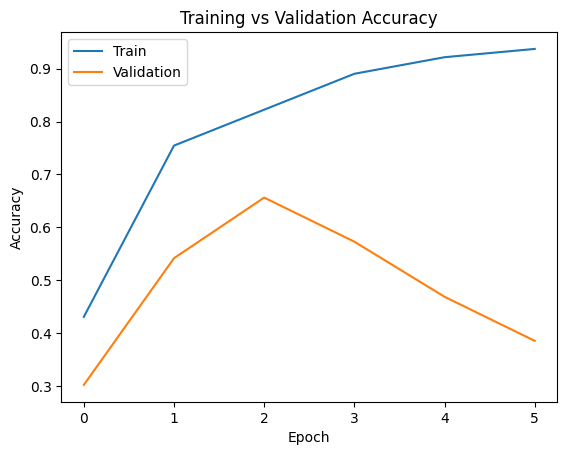

In [24]:
multiclass_best_model = load_model("best_multiclass_cnn.keras", compile=False)

label_map = {
    1: "Class 1",
    2: "Class 2",
    3: "Class 3",
    4: "Class 4",
    5: "Class 5",
    6: "Class 6"
} #Change this to what you want to name your classes 

class_names = [label_map[int(x)] for x in le.classes_]

cm, y_pred = evaluate_multiclass_model(multiclass_best_model, X_test, y_test, class_names)

# ---------- Training curve ----------
plt.plot(history_multi.history['accuracy'], label='Train')
plt.plot(history_multi.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

2b. GRAD-CAM for multiclass CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step


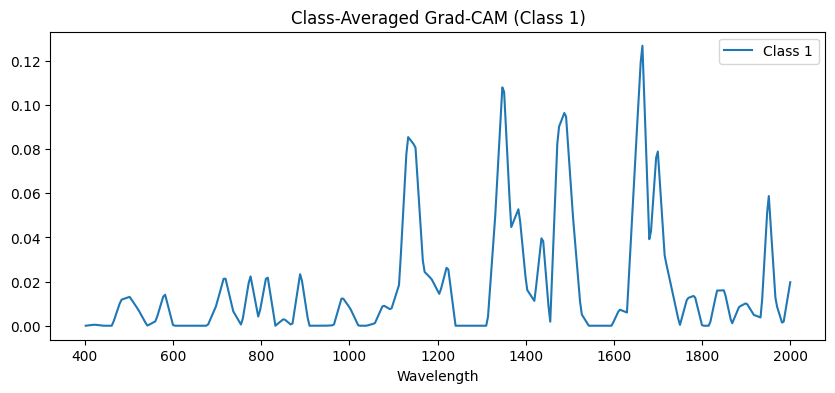


Class 1 — wavenumber importance:
402.1287	0.000000
406.6808	0.000108
411.2303	0.000216
415.7773	0.000325
420.3218	0.000433
424.8639	0.000413
429.4034	0.000305
433.9404	0.000197
438.4749	0.000089
443.0069	0.000000
447.5365	0.000000
452.0635	0.000000
456.5881	0.000000
461.1101	0.000000
465.6297	0.002054
470.1469	0.004712
474.6615	0.007371
479.1736	0.010029
483.6833	0.011835
488.1905	0.012148
492.6953	0.012461
497.1975	0.012775
501.6973	0.013088
506.1946	0.011817
510.6895	0.010471
515.1819	0.009125
519.6719	0.007779
524.1594	0.006280
528.6445	0.004655
533.1271	0.003029
537.6072	0.001404
542.0850	0.000065
546.5602	0.000539
551.0330	0.001013
555.5034	0.001487
559.9714	0.001961
564.4369	0.004244
568.9000	0.007204
573.3607	0.010165
577.8188	0.013126
582.2747	0.014052
586.7280	0.010617
591.1790	0.007182
595.6276	0.003747
600.0737	0.000312
604.5174	0.000000
608.9587	0.000000
613.3976	0.000000
617.8340	0.000000
622.2681	0.000000
626.6998	0.000000
631.1290	0.000000
635.5559	0.000000
639.9803	0.0

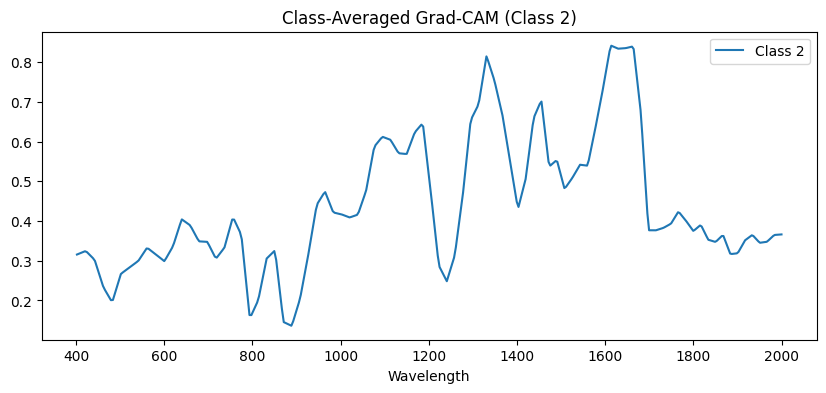


Class 2 — wavenumber importance:
402.1287	0.315600
406.6808	0.317661
411.2303	0.319722
415.7773	0.321783
420.3218	0.323844
424.8639	0.321684
429.4034	0.316600
433.9404	0.311517
438.4749	0.306434
443.0069	0.299419
447.5365	0.283712
452.0635	0.268005
456.5881	0.252299
461.1101	0.236592
465.6297	0.226376
470.1469	0.217775
474.6615	0.209174
479.1736	0.200573
483.6833	0.201038
488.1905	0.217371
492.6953	0.233704
497.1975	0.250037
501.6973	0.266370
506.1946	0.270603
510.6895	0.274259
515.1819	0.277916
519.6719	0.281573
524.1594	0.285284
528.6445	0.289041
533.1271	0.292797
537.6072	0.296554
542.0850	0.300821
546.5602	0.308319
551.0330	0.315818
555.5034	0.323317
559.9714	0.330815
564.4369	0.330079
568.9000	0.326253
573.3607	0.322428
577.8188	0.318603
582.2747	0.314745
586.7280	0.310817
591.1790	0.306888
595.6276	0.302959
600.0737	0.299031
604.5174	0.306541
608.9587	0.315196
613.3976	0.323851
617.8340	0.332506
622.2681	0.344509
626.6998	0.359861
631.1290	0.375212
635.5559	0.390564
639.9803	0.4

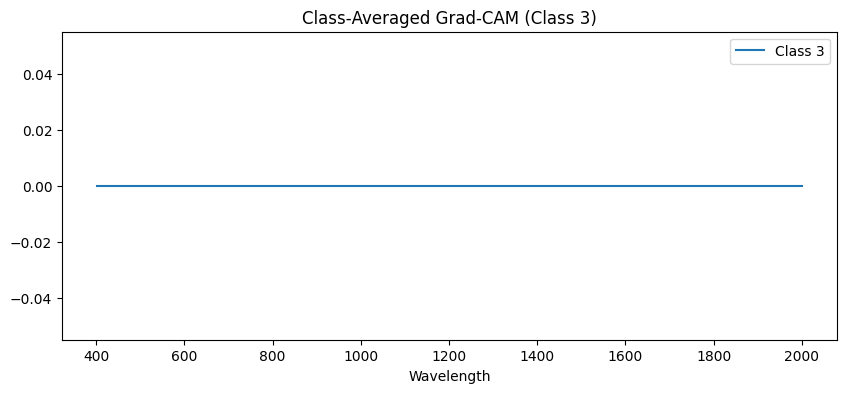


Class 3 — wavenumber importance:
402.1287	0.000000
406.6808	0.000000
411.2303	0.000000
415.7773	0.000000
420.3218	0.000000
424.8639	0.000000
429.4034	0.000000
433.9404	0.000000
438.4749	0.000000
443.0069	0.000000
447.5365	0.000000
452.0635	0.000000
456.5881	0.000000
461.1101	0.000000
465.6297	0.000000
470.1469	0.000000
474.6615	0.000000
479.1736	0.000000
483.6833	0.000000
488.1905	0.000000
492.6953	0.000000
497.1975	0.000000
501.6973	0.000000
506.1946	0.000000
510.6895	0.000000
515.1819	0.000000
519.6719	0.000000
524.1594	0.000000
528.6445	0.000000
533.1271	0.000000
537.6072	0.000000
542.0850	0.000000
546.5602	0.000000
551.0330	0.000000
555.5034	0.000000
559.9714	0.000000
564.4369	0.000000
568.9000	0.000000
573.3607	0.000000
577.8188	0.000000
582.2747	0.000000
586.7280	0.000000
591.1790	0.000000
595.6276	0.000000
600.0737	0.000000
604.5174	0.000000
608.9587	0.000000
613.3976	0.000000
617.8340	0.000000
622.2681	0.000000
626.6998	0.000000
631.1290	0.000000
635.5559	0.000000
639.9803	0.0

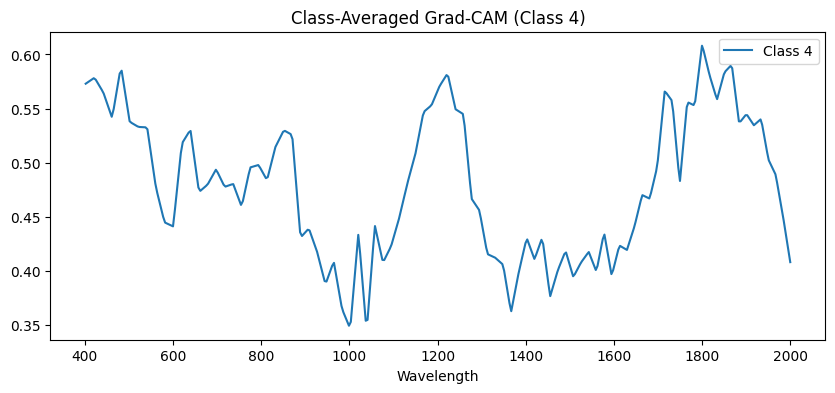


Class 4 — wavenumber importance:
402.1287	0.572987
406.6808	0.574251
411.2303	0.575514
415.7773	0.576778
420.3218	0.578041
424.8639	0.576716
429.4034	0.573598
433.9404	0.570480
438.4749	0.567362
443.0069	0.563840
447.5365	0.558496
452.0635	0.553152
456.5881	0.547809
461.1101	0.542465
465.6297	0.549658
470.1469	0.560538
474.6615	0.571417
479.1736	0.582297
483.6833	0.584982
488.1905	0.573326
492.6953	0.561670
497.1975	0.550013
501.6973	0.538357
506.1946	0.536799
510.6895	0.535722
515.1819	0.534646
519.6719	0.533569
524.1594	0.533026
528.6445	0.532927
533.1271	0.532828
537.6072	0.532729
542.0850	0.530938
546.5602	0.518426
551.0330	0.505915
555.5034	0.493403
559.9714	0.480892
564.4369	0.472127
568.9000	0.464769
573.3607	0.457410
577.8188	0.450051
582.2747	0.444760
586.7280	0.443902
591.1790	0.443044
595.6276	0.442185
600.0737	0.441327
604.5174	0.456995
608.9587	0.474315
613.3976	0.491636
617.8340	0.508956
622.2681	0.519081
626.6998	0.522010
631.1290	0.524940
635.5559	0.527869
639.9803	0.5

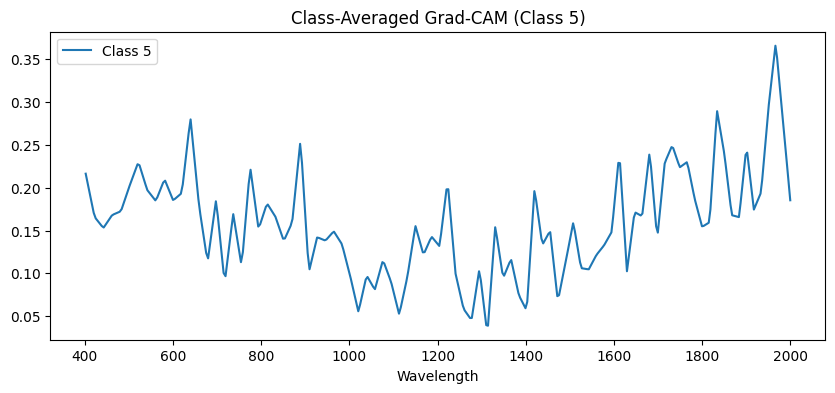


Class 5 — wavenumber importance:
402.1287	0.216345
406.6808	0.204912
411.2303	0.193479
415.7773	0.182045
420.3218	0.170612
424.8639	0.164190
429.4034	0.161237
433.9404	0.158284
438.4749	0.155331
443.0069	0.153542
447.5365	0.156994
452.0635	0.160446
456.5881	0.163898
461.1101	0.167349
465.6297	0.168908
470.1469	0.169909
474.6615	0.170911
479.1736	0.171912
483.6833	0.175027
488.1905	0.181841
492.6953	0.188654
497.1975	0.195467
501.6973	0.202281
506.1946	0.208577
510.6895	0.214848
515.1819	0.221119
519.6719	0.227390
524.1594	0.226181
528.6445	0.218740
533.1271	0.211298
537.6072	0.203856
542.0850	0.197027
546.5602	0.194084
551.0330	0.191140
555.5034	0.188196
559.9714	0.185252
564.4369	0.188656
568.9000	0.194441
573.3607	0.200225
577.8188	0.206010
582.2747	0.208167
586.7280	0.202551
591.1790	0.196935
595.6276	0.191319
600.0737	0.185703
604.5174	0.186975
608.9587	0.188937
613.3976	0.190898
617.8340	0.192859
622.2681	0.203816
626.6998	0.223770
631.1290	0.243723
635.5559	0.263676
639.9803	0.2

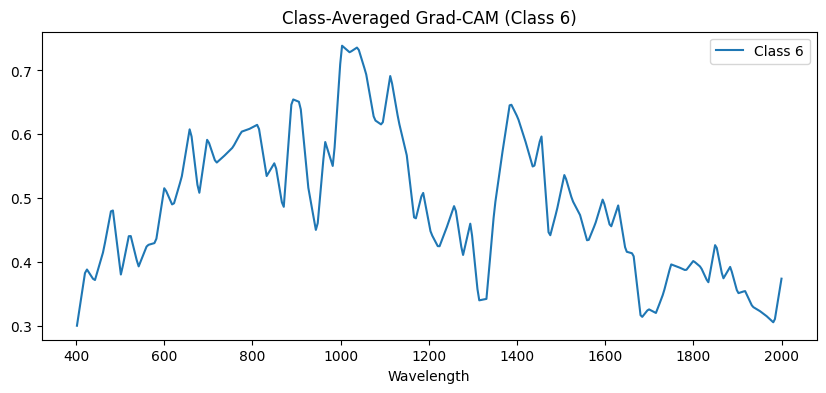


Class 6 — wavenumber importance:
402.1287	0.300044
406.6808	0.320666
411.2303	0.341287
415.7773	0.361908
420.3218	0.382529
424.8639	0.388117
429.4034	0.383298
433.9404	0.378479
438.4749	0.373660
443.0069	0.371667
447.5365	0.382394
452.0635	0.393121
456.5881	0.403848
461.1101	0.414574
465.6297	0.429762
470.1469	0.446262
474.6615	0.462761
479.1736	0.479261
483.6833	0.480636
488.1905	0.455543
492.6953	0.430450
497.1975	0.405357
501.6973	0.380264
506.1946	0.393895
510.6895	0.409369
515.1819	0.424843
519.6719	0.440317
524.1594	0.440500
528.6445	0.427939
533.1271	0.415379
537.6072	0.402818
542.0850	0.393028
546.5602	0.400786
551.0330	0.408543
555.5034	0.416301
559.9714	0.424059
564.4369	0.426826
568.9000	0.427722
573.3607	0.428618
577.8188	0.429514
582.2747	0.436413
586.7280	0.456174
591.1790	0.475936
595.6276	0.495697
600.0737	0.515459
604.5174	0.510946
608.9587	0.504005
613.3976	0.497064
617.8340	0.490124
622.2681	0.491867
626.6998	0.502294
631.1290	0.512721
635.5559	0.523148
639.9803	0.5

In [25]:

label_map = {
    1: "Class 1",
    2: "Class 2",
    3: "Class 3",
    4: "Class 4",
    5: "Class 5",
    6: "Class 6"
}


def gradcam_1d(model, x, class_index=None, conv_layer_name=None):
    if conv_layer_name is None:
        conv_candidates = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv1D)]
        if not conv_candidates:
            raise ValueError("No Conv1D layers found in model.")
        conv_layer_name = conv_candidates[-1]

    x_in = tf.keras.Input(shape=x.shape[1:])
    h = x_in
    conv_out = None

    for layer in model.layers:
        h = layer(h)
        if layer.name == conv_layer_name:
            conv_out = h

    if conv_out is None:
        raise ValueError(f"Layer {conv_layer_name} not found in model.")

    grad_model = tf.keras.models.Model(x_in, [conv_out, h])

    with tf.GradientTape() as tape:
        conv_out_val, preds = grad_model(x)
        if class_index is None:
            class_index = tf.argmax(preds[0])
        class_score = preds[:, class_index]

    grads = tape.gradient(class_score, conv_out_val)
    weights = tf.reduce_mean(grads, axis=1)
    cam = tf.reduce_sum(conv_out_val * weights[:, None, :], axis=-1)
    cam = tf.nn.relu(cam)[0].numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, int(class_index)

def class_average_gradcam(model, X, y, target_class, conv_layer_name=None):
    cams = []
    for i in range(len(X)):
        if y[i] != target_class:
            continue
        cam, _ = gradcam_1d(model, X[i:i+1], class_index=target_class, conv_layer_name=conv_layer_name)
        cams.append(cam)

    if len(cams) == 0:
        raise ValueError("No samples found for that class.")
    return np.mean(cams, axis=0)

# ---- Wavelength axis from CSV header ----
df = pd.read_csv(data_path_multi)
wavelengths = df.columns[:-1].astype(float).to_numpy()

# ---- Ensure model is built ----
_ = multiclass_best_model.predict(X_test[:1])


# ---- One plot per class ----
for orig_label in range(1, 7):
    encoded_label = np.where(le.classes_ == orig_label)[0][0]

    avg_cam = class_average_gradcam(
        multiclass_best_model, X_test, y_test,
        target_class=encoded_label
    )

    avg_cam_resized = np.interp(
        np.linspace(0, len(avg_cam) - 1, len(wavelengths)),
        np.arange(len(avg_cam)),
        avg_cam
    )

    plt.figure(figsize=(10,4))
    plt.plot(wavelengths, avg_cam_resized, label=label_map[orig_label])
    plt.xlabel("Wavelength")
    plt.title(f"Class‑Averaged Grad‑CAM ({label_map[orig_label]})")
    plt.legend()
    plt.show()
    
    # Print wavenumber-importance list for this class
    wavenumber_importance = list(zip(wavelengths, avg_cam_resized))
    print(f"\n{label_map[orig_label]} — wavenumber importance:")
    for wn, imp in wavenumber_importance:
        print(f"{wn:.4f}\t{imp:.6f}")